nltools.data.brain_data.Brain_Data(data=(50, 238955), Y=(0, 0), X=(0, 0), mask=MNI152_T1_2mm_brain_mask.nii.gz)

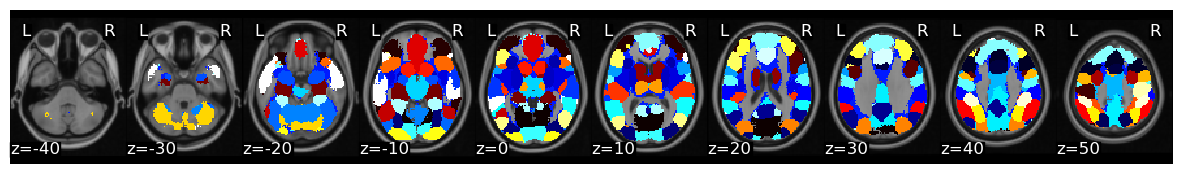

In [11]:
import os
from nltools.mask import expand_mask, roi_to_brain
from nltools.data import Brain_Data, Adjacency

# from fnl_tools.stats import (compute_ISC_all_roi,
#                              create_average_concordance)
from nltools.stats import (threshold, 
                           align,
                           fdr, 
                           isc,
                           _calc_pvalue)
from scipy import stats
import numpy as np
from nltools.prefs import MNI_Template
import warnings
warnings.filterwarnings('ignore')

MNI_Template['resolution'] = '2mm' ## mask specify

base_dir = '/Storage/Data/nes/'
current_directory = '/Storage/Data/nes_menghan/code_menghan/NeuroExperience/'
svg_file = 'svg_files' ## svg plots

mask = Brain_Data(os.path.join(base_dir, 'code_menghan', 'Mask', 'k50_2mm.nii.gz'))
mask.plot()
#expand this mask into 50 separate regions
mask_x = expand_mask(mask) 
mask_x

In [12]:
data_dir = '/Storage/Data/nes_menghan/preprocessed/final/'
subj_sids_list = os.listdir(data_dir)
subj_sids_iteration = []
for subj in subj_sids_list:
    subj_path = os.path.join(data_dir, subj)
    subj_path_sess = os.listdir(subj_path)
    if len(subj_path_sess) == 5:
        subj_sids_iteration.append(subj)
    
    
subj_sids_iteration.remove('sub-sid001215') ###the Timepoints of this subject's third session were fewer than others
subj_sids_iteration.remove('sub-sid001473') ### the fifth

subj_sids_iteration.remove('sub-sid000860') 
subj_sids_iteration.remove('sub-sid001201')  ### head coil issue: HEP
print(len(subj_sids_iteration))
subj_sids_iteration

20


['sub-sid001377',
 'sub-sid001277',
 'sub-sid001280',
 'sub-sid001367',
 'sub-sid000846',
 'sub-sid001274',
 'sub-sid001397',
 'sub-sid001358',
 'sub-sid001276',
 'sub-sid000381',
 'sub-sid001286',
 'sub-sid001282',
 'sub-sid000854',
 'sub-sid001555',
 'sub-sid001291',
 'sub-sid000780',
 'sub-sid001302',
 'sub-sid001296',
 'sub-sid001278',
 'sub-sid000861']

In [13]:
import pandas as pd

onset_movie = os.path.join('/Storage/Data/nes_menghan/', 'code_menghan', 'NeuroExperience','onset_movie.txt')

onset_movie = pd.read_csv(onset_movie,sep='\t').set_index('Movie name')
onset_movie

,Scanning run,Starting TR,Ending TR,Trim_Starting TR,Trim_Ending TR,Entire Onset,Entire Ending
Movie name,,,,,,,
Nature,run1,8,52,3,47,3,47
Asian cake,run1,62,185,57,180,57,180
Ribbon climbing,run1,194,335,189,330,189,330
Kiss me,run1,344,485,339,480,339,480
Syrian,run1,495,584,490,579,490,579
Salad,run2,8,138,3,133,591,721
Angelina Hale,run2,147,277,142,272,730,860
Soccer,run2,285,410,280,405,868,993
Dancing lady,run2,419,529,414,524,1002,1112


In [14]:
import numpy as np
auto_matrix = [[1,1,2/3,1/3,0],
               [1,1,1,2/3,1/3],
               [2/3,1,1,1,2/3],
               [1/3,2/3,1,1,1],
               [0,1/3,2/3,1,1]]
auto_matrix = np.array(auto_matrix)
auto_matrix[[0,1,2,3,4],[0,1,2,3,4]] = np.nan

sess_matrix = [[1,1,1,1,1],
               [1,1,2/3,2/3,2/3],
               [1,2/3,1,1/3,1/3],
               [1,2/3,1/3,1,0],
               [1,2/3,1/3,0,1]]
sess_matrix = np.array(sess_matrix).T
sess_matrix[[0,1,2,3,4],[0,1,2,3,4]] = np.nan


sess_matrix_trail = sess_matrix[np.triu_indices(5, 1)]
auto_matrix_trail = auto_matrix[np.triu_indices(5, 1)]


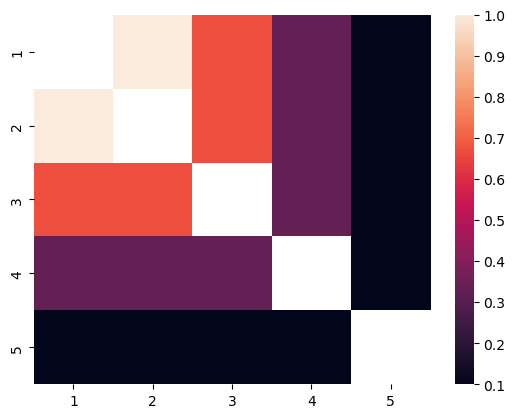

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
auto_session_matrix = (auto_matrix + sess_matrix)/2
auto_session_matrix = np.array(auto_session_matrix)
auto_session_matrix[[0,1,2,3,4],[0,1,2,3,4]] = np.nan


from sklearn.preprocessing import MinMaxScaler
from sklearn import preprocessing as pre
#reshape array so that it works with sklearn
x = auto_session_matrix.reshape(-1, 1)

#normalize all values to be between 0 and 1
x_norm = pre.MinMaxScaler().fit_transform(x)
auto_session_matrix = x_norm.reshape(5, 5)


yticks = [1,2,3,4,5]

g = sns.heatmap(auto_session_matrix,mask=pd.DataFrame(auto_session_matrix).isnull(),vmin = 0.1,yticklabels=yticks,xticklabels=yticks)
g.set_facecolor('xkcd:white')
plt.savefig(os.path.join(current_directory,svg_file,"combined_effects.svg"), format="svg")


In [9]:
from tqdm.notebook import tqdm
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


session_num = 5
roi_all = mask_x.data.shape[0]

ROI_corr_effects_all = []
for roi_num in tqdm(range(roi_all)):
    ISC_within_corr_all = []
    for subid,sub_name in enumerate(subj_sids_iteration):
        data_subj_session = pd.DataFrame([])
        isc_data = glob.glob(os.path.join('/Storage/Data/nes_menghan/denoised/Denoised_ROI',f"{sub_name}_ses*_Denoised_ROI_{roi_num}.csv"))
        isc_data.sort()
        for i in range(session_num):
            isc_data_session = pd.read_csv(isc_data[i])
            if len(data_subj_session) == 0:
                data_subj_session = isc_data_session
            else:
                data_subj_session = np.concatenate((data_subj_session,isc_data_session),axis = 1)

        video_corr = []
    #         video_corr_data = []
        for video_label in range(24):
            video_sess = []
            video_onset = onset_movie['Entire Onset'][video_label]-1
            video_end = onset_movie['Entire Ending'][video_label]-1
            video_sess = data_subj_session[video_onset:video_end+1,:] 

            video_data = pd.DataFrame(video_sess)
    #             video_data = video_data.T
            video_data_corr = video_data.corr()
            ISC_within_corr_all.append(video_data_corr.values.tolist())
            
            
    ISC_within_corr_all_np = np.array(ISC_within_corr_all)
    ISC_within_corr_all_np_reshape = ISC_within_corr_all_np.reshape(20,24,5,5)
    
    ROI_corr_effects = []
    for m in range(24):
        for n in range(20):
        
            session_matrix = ISC_within_corr_all_np_reshape[n,m,:,:]

            y_array = session_matrix[np.triu_indices(5, 1)] 
            y_array_z = stats.zscore(y_array)
            sess_auto_trail_z = stats.zscore(sess_auto_trail)

            data = pd.DataFrame(np.array([sess_auto_trail_z,y_array_z]).reshape(2,-1).T,columns = ['Adjacency and Repeating','temporal corr'])
            ROI_corr = data.corr().iloc[1,0]
        
            ROI_corr_effects.append(ROI_corr)
   
    
    ROI_corr_effects_all.append(ROI_corr_effects)

    

  0%|          | 0/50 [00:00<?, ?it/s]

NameError: name 'sess_auto_trail' is not defined

In [109]:
ROI_corr_effects_all_np = np.array(ROI_corr_effects_all)
ROI_corr_effects_all_np_mean = np.mean(ROI_corr_effects_all_np,axis = 1)

In [236]:
from sklearn import preprocessing as pre

ROI_corr_effects_all_np_mean = ROI_corr_effects_all_np_mean.reshape(-1, 1)
ROI_corr_effects_all_np_mean_norm = pre.MinMaxScaler(feature_range=(-0.3, 1)).fit_transform(ROI_corr_effects_all_np_mean)

In [237]:
ROI_corr_effects_all_np_mean_norm = ROI_corr_effects_all_np_mean_norm.reshape(50)

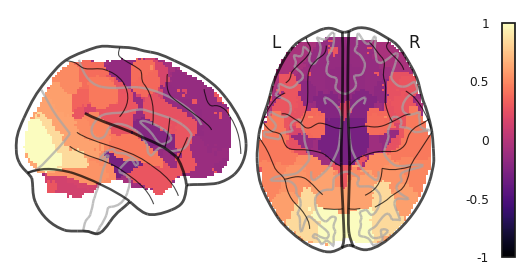

In [238]:
from nilearn.plotting import plot_glass_brain

roi_corr_brain = roi_to_brain(ROI_corr_effects_all_np_mean_norm, mask_x)
cmap='magma'
display = plot_glass_brain(roi_corr_brain.to_nifti(), display_mode='xz',colorbar=True,cmap=cmap, plot_abs=False,vmin=-1, vmax = 1)

plt.savefig(os.path.join(current_directory,svg_file,"combined_effect_brain.svg"), format="svg")

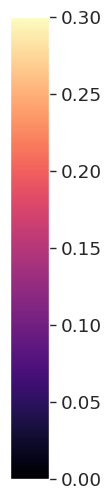

In [240]:
import matplotlib as mpl
with sns.plotting_context(context='paper', font_scale=1.5):
    fig, ax = plt.subplots(figsize=(0.5, 6))
    cmap = mpl.colormaps['magma']
    norm = mpl.colors.Normalize(vmin=0, vmax=0.3)
    cb1 = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical')

    plt.savefig(os.path.join(current_directory,svg_file,"combined_effect_brain_cmap.svg"), format="svg")


## proximity and repetition effects

In [16]:
from scipy import stats
import pingouin as pg
import numpy as np
from tqdm.notebook import tqdm
import glob
from scipy import stats


session_num = 5

onset_movie = os.path.join('/Storage/Data/nes_menghan/', 'code_menghan', 'NeuroExperience','onset_movie.txt')
onset_movie = pd.read_csv(onset_movie,sep='\t').set_index('Movie name')


roi_all = mask_x.data.shape[0]
Beta_session = []
Beta_autocorr = []




for roi_num in tqdm(range(roi_all)):
    ISC_within_corr_all = []
    for sub_name in tqdm(subj_sids_iteration):
        data_subj_session = pd.DataFrame([])
        isc_data = glob.glob(os.path.join('/Storage/Data/nes_menghan/denoised/Denoised_ROI',f"{sub_name}_ses*_Denoised_ROI_{roi_num}.csv"))
        isc_data.sort()
        for i in range(session_num):
            isc_data_session = pd.read_csv(isc_data[i])
            if len(data_subj_session) == 0:
                data_subj_session = isc_data_session
            else:
                data_subj_session = np.concatenate((data_subj_session,isc_data_session),axis = 1)

        video_corr = []
    #         video_corr_data = []
        for video_label in range(24):
            video_sess = []
            video_onset = onset_movie['Entire Onset'][video_label]-1
            video_end = onset_movie['Entire Ending'][video_label]-1
            video_sess = data_subj_session[video_onset:video_end+1,:] 

            video_data = pd.DataFrame(video_sess)
    #             video_data = video_data.T
            video_data_corr = video_data.corr()
            ISC_within_corr_all.append(video_data_corr.values.tolist())
            
            
    ISC_within_corr_all_np = np.array(ISC_within_corr_all)
    ISC_within_corr_all_np_reshape = ISC_within_corr_all_np.reshape(20,24,5,5)
    
    ROI_beta_temporal_mean = pd.DataFrame([])
    for m in range(24):
        
        for n in range(20):
        
            session_matrix = ISC_within_corr_all_np_reshape[n,m,:,:]
                    
            y_array = session_matrix[np.triu_indices(5, 1)]
#             y_array_z = stats.zscore(y_array)
#             auto_matrix_trail_z = stats.zscore(auto_matrix_trail)
#             sess_matrix_trail_z = stats.zscore(sess_matrix_trail)

            data = pd.DataFrame(np.array([auto_matrix_trail,sess_matrix_trail,y_array]).reshape(3,-1).T,columns = ['Adjacency','Repeating','temporal corr'])
            results_linear_session_autocorr = pg.linear_regression(data.iloc[:,0:2], data['temporal corr'])

        
            individual_pd = results_linear_session_autocorr.iloc[1:3,0:2]
            individual_pd['participants'] = subj_sids_iteration[n]
            individual_pd['video'] = onset_movie.index[m]

            ROI_beta_temporal_mean = pd.concat([ROI_beta_temporal_mean,individual_pd])
   
    
    Beta_session.append(ROI_beta_temporal_mean[ROI_beta_temporal_mean['names'] == 'Repeating']['coef'].mean())
    Beta_autocorr.append(ROI_beta_temporal_mean[ROI_beta_temporal_mean['names'] == 'Adjacency']['coef'].mean())
    

    

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

...

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

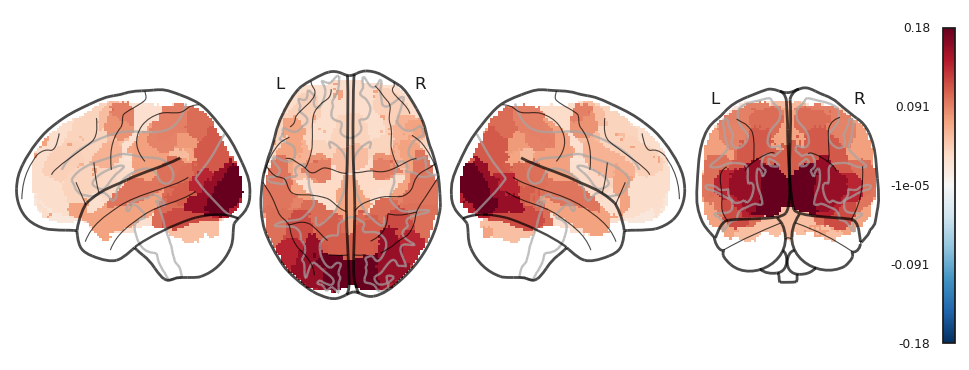

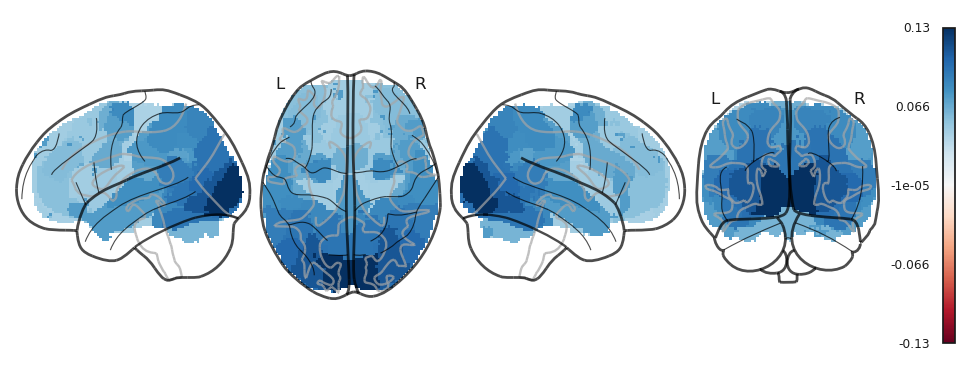

In [18]:
from nilearn.plotting import plot_glass_brain
import seaborn as sns

sns.set(font_scale=0.8)

Beta_session_brain = roi_to_brain(Beta_session, mask_x)
plot_glass_brain(Beta_session_brain.to_nifti(), display_mode='lzry',colorbar=True,cmap='RdBu_r',plot_abs=False, symmetric_cbar=True)
plt.savefig(os.path.join(current_directory,svg_file,"repetition_entire_brain.svg"), format="svg")

Beta_autocorr_brain = roi_to_brain(Beta_autocorr, mask_x)
plot_glass_brain(Beta_autocorr_brain.to_nifti(), display_mode='lzry',colorbar=True,cmap='RdBu',plot_abs=False, symmetric_cbar=True)
plt.savefig(os.path.join(current_directory,svg_file,"proximity_entire_brain.svg"), format="svg")


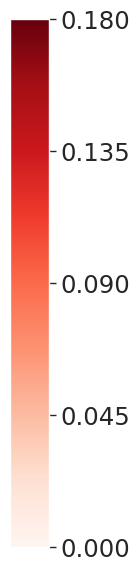

In [24]:

import matplotlib as mpl
with sns.plotting_context(context='paper', font_scale=2):
    fig, ax = plt.subplots(figsize=(0.5, 6))
    fig.subplots_adjust(bottom=0)

    cmap = mpl.cm.Reds
    norm = mpl.colors.Normalize(vmin=0, vmax=0.18)
    cb1 = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical', ticks=np.linspace(0, 0.18, 5))
    plt.tight_layout()
    plt.savefig(os.path.join(current_directory,svg_file,"repetition_entire_brain_cmap.svg"), format="svg")

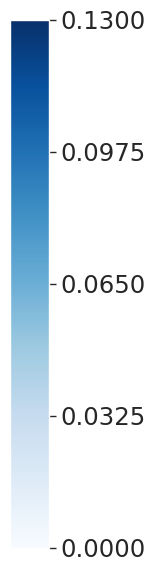

In [23]:

import matplotlib as mpl
with sns.plotting_context(context='paper', font_scale=2):
    fig, ax = plt.subplots(figsize=(0.5, 6))
    fig.subplots_adjust(bottom=0)

    cmap = mpl.cm.Blues
    norm = mpl.colors.Normalize(vmin=0, vmax=0.13)
    cb1 = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical', ticks=np.linspace(0, 0.13, 5))
    plt.tight_layout()
    plt.savefig(os.path.join(current_directory,svg_file,"proximity_entire_brain_cmap.svg"), format="svg")

In [13]:
ROI_beta_temporal_mean[ROI_beta_temporal_mean['names'] == 'Repeating'].groupby('participants')['coef'].mean()

participants
sub-sid000381    0.084365
sub-sid000780    0.072298
sub-sid000846    0.074720
sub-sid000854    0.144447
sub-sid000861    0.092785
sub-sid001274    0.016206
sub-sid001276    0.089032
sub-sid001277   -0.005748
sub-sid001278   -0.029235
sub-sid001280    0.182723
sub-sid001282    0.067582
sub-sid001286    0.116929
sub-sid001291    0.086903
sub-sid001296    0.103738
sub-sid001302   -0.052021
sub-sid001358    0.126785
sub-sid001367    0.027658
sub-sid001377   -0.005706
sub-sid001397    0.191695
sub-sid001555    0.081524
Name: coef, dtype: float64

In [25]:
from scipy import stats
import pingouin as pg
import numpy as np
from tqdm.notebook import tqdm
import glob

roi_all = mask_x.data.shape[0]
Beta_session = pd.DataFrame()
Beta_autocorr = pd.DataFrame()

for roi_num in tqdm(range(roi_all)):
    ISC_within_corr_all = []
    for subid,sub_name in enumerate(subj_sids_iteration):
        data_subj_session = pd.DataFrame([])
        isc_data = glob.glob(os.path.join('/Storage/Data/nes_menghan/denoised/Denoised_ROI',f"{sub_name}_ses*_Denoised_ROI_{roi_num}.csv"))
        isc_data.sort()
        for i in range(session_num):
            isc_data_session = pd.read_csv(isc_data[i])
            if len(data_subj_session) == 0:
                data_subj_session = isc_data_session
            else:
                data_subj_session = np.concatenate((data_subj_session,isc_data_session),axis = 1)

        video_corr = []
    #         video_corr_data = []
        for video_label in range(24):
            video_sess = []
            video_onset = onset_movie['Entire Onset'][video_label]-1
            video_end = onset_movie['Entire Ending'][video_label]-1
            video_sess = data_subj_session[video_onset:video_end+1,:] 

            video_data = pd.DataFrame(video_sess)
    #             video_data = video_data.T
            video_data_corr = video_data.corr()
            ISC_within_corr_all.append(video_data_corr.values.tolist())
            
            
    ISC_within_corr_all_np = np.array(ISC_within_corr_all)
    ISC_within_corr_all_np_reshape = ISC_within_corr_all_np.reshape(20,24,5,5)
    
    ROI_beta_temporal_mean = pd.DataFrame([])
    for m in range(24):
        for n in range(20):
        
            session_matrix = ISC_within_corr_all_np_reshape[n,m,:,:]

            y_array = session_matrix[np.triu_indices(5, 1)]

            data = pd.DataFrame(np.array([auto_matrix_trail,sess_matrix_trail,y_array]).reshape(3,-1).T,columns = ['Adjacency','Repeating','temporal corr'])
            results_linear_session_autocorr = pg.linear_regression(data.iloc[:,0:2], data['temporal corr'])

        
            individual_pd = results_linear_session_autocorr.iloc[1:3,0:2]
            individual_pd['participants'] = subj_sids_iteration[n]
            individual_pd['video'] = onset_movie.index[m]

            ROI_beta_temporal_mean = pd.concat([ROI_beta_temporal_mean,individual_pd])
   
    
    Beta_session = pd.concat([Beta_session,ROI_beta_temporal_mean[ROI_beta_temporal_mean['names'] == 'Repeating'].groupby('participants')['coef'].mean()],axis = 1)
    Beta_autocorr = pd.concat([Beta_autocorr,ROI_beta_temporal_mean[ROI_beta_temporal_mean['names'] == 'Adjacency'].groupby('participants')['coef'].mean()],axis = 1)
  

    

  0%|          | 0/50 [00:00<?, ?it/s]

In [26]:
individual_pd

,names,coef,participants,video
1,Adjacency,-0.084180,sub-sid000861,Ingrid Silva
2,Repeating,0.238229,sub-sid000861,Ingrid Silva


In [26]:
Beta_session_all = Brain_Data()
for sub_id in range(20):
    Beta_session_brain = roi_to_brain(Beta_session.iloc[sub_id,:]-Beta_autocorr.iloc[sub_id,:], mask_x)
    Beta_session_all = Beta_session_all.append(Beta_session_brain)

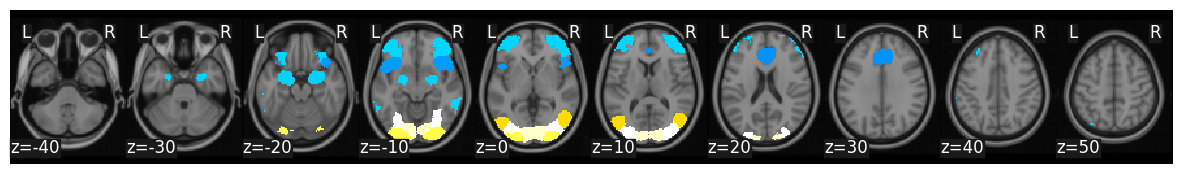

In [136]:
stats = Beta_session_all.ttest(threshold_dict = {'unc':.05})
stats['thr_t'].plot()

In [133]:
stats

{'t': nltools.data.brain_data.Brain_Data(data=(238955,), Y=0, X=(0, 0), mask=MNI152_T1_2mm_brain_mask.nii.gz),
 'p': nltools.data.brain_data.Brain_Data(data=(238955,), Y=0, X=(0, 0), mask=MNI152_T1_2mm_brain_mask.nii.gz),
 'thr_t': nltools.data.brain_data.Brain_Data(data=(238955,), Y=0, X=(0, 0), mask=MNI152_T1_2mm_brain_mask.nii.gz)}

In [32]:
from nltools.stats import (threshold, 
                           align,
                           fdr, 
                           isc,
                           _calc_pvalue)
from scipy import stats

roi_p = {}
for roi in range(50):
    roi_diff = Beta_session.iloc[:,roi]-Beta_autocorr.iloc[:,roi]
    roi_diff_t = stats.ttest_1samp(roi_diff,popmean = 0)
    roi_p[roi] = roi_diff_t.pvalue

# fdr_thr = fdr(np.array(list(roi_p.values())))
sig_roi = np.array(list(roi_p.keys()))[np.array(list(roi_p.values()) < np.array(0.05))]

In [33]:
roi_p

{0: 0.04821673578081769,
 1: 0.1256878789339271,
 2: 0.1751477458617548,
 3: 0.07585388987561141,
 4: 0.0028979745044245006,
 5: 0.5263197634692457,
 6: 0.7376137284374389,
 7: 0.05312414400077289,
 8: 0.2671715853658739,
 9: 0.3613920881241689,
 10: 0.7985865681882001,
 11: 0.06813406013777872,
 12: 0.02513443753097678,
 13: 0.1596428518549734,
 14: 0.10091032825198172,
 15: 0.9136461309172104,
 16: 0.08482891574943915,
 17: 0.15023749552455595,
 18: 0.06783371742098995,
 19: 0.310111803235358,
 20: 0.001836754434648612,
 21: 0.28175435239174923,
 22: 0.16612462093162095,
 23: 0.4169114911508839,
 24: 0.23508562414293216,
 25: 0.02339276701978899,
 26: 0.16680256063338447,
 27: 0.7263529662668776,
 28: 0.07840849924176367,
 29: 0.10071737686636593,
 30: 0.4921965311982385,
 31: 0.2708179997889846,
 32: 0.05305525754239177,
 33: 0.21738888829575376,
 34: 0.06481658876407666,
 35: 0.6960183135017616,
 36: 0.5422257052099912,
 37: 0.04438924338643821,
 38: 0.2033458128532328,
 39: 0.2858

In [30]:
sig_roi

array([ 0,  4, 12, 20, 25, 37, 43, 46])

In [23]:
Beta_session

,coef,coef,coef,coef,coef,coef,coef,coef,coef,coef,...,coef,coef,coef,coef,coef,coef,coef,coef,coef,coef
sub-sid000381,-0.044755,0.101737,-0.025971,-0.025727,0.225000,0.104701,-0.035559,0.049652,0.004778,0.005492,...,0.003728,0.031355,-0.014659,0.175933,-0.053461,0.030934,0.192866,-0.011777,0.032708,0.084365
sub-sid000780,-0.051012,0.082109,-0.041979,-0.022136,0.132770,0.067794,0.027514,0.007523,-0.004829,-0.015340,...,0.026312,0.000391,0.029273,0.162084,-0.002071,-0.034246,0.138251,-0.010834,0.033735,0.072298
sub-sid000846,-0.004758,0.093313,0.063669,0.031665,0.118892,0.036986,0.041480,0.060709,0.042181,0.041562,...,0.039163,0.053813,0.054345,0.050562,0.037705,0.085079,0.066024,0.033694,0.115392,0.074720
sub-sid000854,0.093586,0.231120,0.056743,0.092081,0.259415,0.189999,0.219854,0.004648,0.087768,0.061291,...,0.114195,0.077423,0.142790,0.224799,0.085970,0.083265,0.183813,0.095984,0.120624,0.144447
sub-sid000861,0.078178,0.071060,0.035404,0.034171,0.064040,0.069190,0.052396,0.057167,0.064530,0.071546,...,0.091598,0.100175,0.063651,0.045390,0.134750,0.061965,0.040667,0.030568,0.103562,0.092785
sub-sid001274,0.028819,0.006097,0.027306,-0.019357,-0.012586,0.022715,0.014933,-0.023544,-0.034871,-0.018671,...,-0.037637,-0.011304,-0.006065,0.020795,0.002300,0.013902,0.021741,0.022656,0.011188,0.016206
sub-sid001276,0.143445,0.145419,0.104649,0.082490,0.391505,0.247627,0.219334,0.009126,0.087484,0.092769,...,0.234850,0.154693,0.142959,0.301929,0.149083,0.004998,0.214433,0.090115,0.141249,0.089032
sub-sid001277,0.051633,0.090307,0.037865,-0.009427,0.208813,0.007957,0.077494,0.016149,0.047942,0.011291,...,0.042107,0.032454,0.068792,0.158507,0.124531,-0.011047,0.123534,-0.023729,0.071208,-0.005748
sub-sid001278,0.009658,0.017138,-0.023883,0.023590,0.032909,-0.031696,-0.026434,-0.038951,0.014546,0.031345,...,-0.017762,-0.030139,0.021299,0.030380,0.035555,0.001472,0.020016,0.038644,0.038257,-0.029235
sub-sid001280,0.065608,0.219821,0.154920,0.111539,0.296330,0.210308,0.186830,0.022351,0.081751,0.121989,...,0.109849,0.114063,0.203765,0.214191,0.090226,0.091779,0.316640,0.111134,0.213442,0.182723


In [43]:
def find_keys_with_values_smaller_than(d, threshold=0.01):
    return [key for key, value in d.items() if value < threshold]

result = find_keys_with_values_smaller_than(roi_p)
print(result)

[4, 20, 43]


In [15]:
roi_diff_all = []
for roi in range(50):
    roi_diff = Beta_session.iloc[:,roi]-Beta_autocorr.iloc[:,roi]
    roi_diff_all.append(roi_diff.values.mean())
    

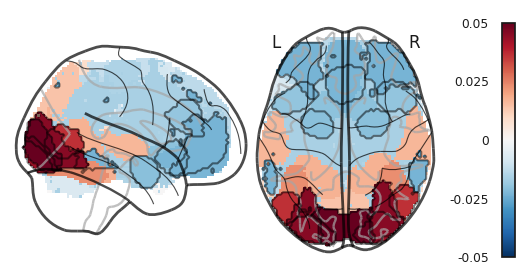

In [140]:
roi_diff_all_brain = roi_to_brain(roi_diff_all, mask_x)
display = plot_glass_brain(roi_diff_all_brain.to_nifti(), display_mode='xz',colorbar=True,cmap='RdBu_r',plot_abs=False, symmetric_cbar=True)

[display.add_contours(mask_x[x].to_nifti(), levels=[0.5], colors='black', alpha=.5) for x in sig_roi]
plt.savefig(os.path.join(current_directory,svg_file,"entire_brain_difference.svg"), format="svg")

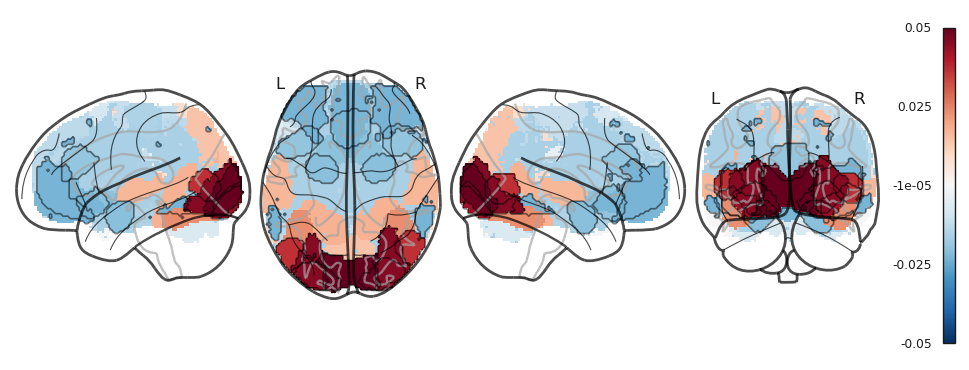

In [20]:
import matplotlib as mpl
with sns.plotting_context(context='paper', font_scale=1):
    roi_diff_all_brain = roi_to_brain(roi_diff_all, mask_x)
    display = plot_glass_brain(roi_diff_all_brain.to_nifti(), display_mode='lzry',colorbar=True,cmap='RdBu_r',plot_abs=False, symmetric_cbar=True)
    
    [display.add_contours(mask_x[x].to_nifti(), levels=[0.5], colors='black', alpha=.5) for x in sig_roi]
    plt.savefig(os.path.join(current_directory,svg_file,"entire_brain_difference_all.svg"), format="svg")

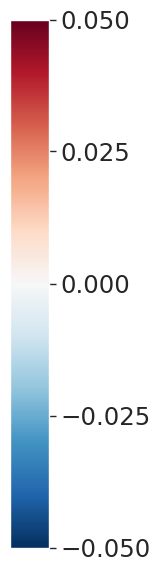

In [21]:
import matplotlib as mpl
with sns.plotting_context(context='paper', font_scale=2):
    fig, ax = plt.subplots(figsize=(0.5, 6))
    fig.subplots_adjust(bottom=0)

    cmap = mpl.cm.RdBu_r
    norm = mpl.colors.Normalize(vmin=-0.05, vmax=0.05)
    cb1 = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical', ticks=np.linspace(-0.05, 0.05, 5))
    plt.tight_layout()
    plt.savefig(os.path.join(current_directory,svg_file,"entire_brain_difference_all_cmap.svg"), format="svg")
    

### use mixed effect model to test stats

In [7]:
from scipy import stats
import pingouin as pg
import numpy as np
from tqdm.notebook import tqdm
import glob
from pymer4.models import Lmer

roi_all = mask_x.data.shape[0]
stats_t = []
stats_p = []
session_num = 5

for roi_num in tqdm(range(roi_all)):
    ISC_within_corr_all = []
    for subid,sub_name in enumerate(subj_sids_iteration):
        data_subj_session = pd.DataFrame([])
        isc_data = glob.glob(os.path.join('/Storage/Data/nes_menghan/denoised/Denoised_ROI',f"{sub_name}_ses*_Denoised_ROI_{roi_num}.csv"))
        isc_data.sort()
        for i in range(session_num):
            isc_data_session = pd.read_csv(isc_data[i])
            if len(data_subj_session) == 0:
                data_subj_session = isc_data_session
            else:
                data_subj_session = np.concatenate((data_subj_session,isc_data_session),axis = 1)

        video_corr = []
    #         video_corr_data = []
        for video_label in range(24):
            video_sess = []
            video_onset = onset_movie['Entire Onset'][video_label]-1
            video_end = onset_movie['Entire Ending'][video_label]-1
            video_sess = data_subj_session[video_onset:video_end+1,:] 

            video_data = pd.DataFrame(video_sess)
    #             video_data = video_data.T
            video_data_corr = video_data.corr()
            ISC_within_corr_all.append(video_data_corr.values.tolist())
            
            
    ISC_within_corr_all_np = np.array(ISC_within_corr_all)
    ISC_within_corr_all_np_reshape = ISC_within_corr_all_np.reshape(20,24,5,5)
    
    ROI_beta_temporal_mean = pd.DataFrame([])
    for m in range(24):
        for n in range(20):
        
            session_matrix = ISC_within_corr_all_np_reshape[n,m,:,:]

            y_array = session_matrix[np.triu_indices(5, 1)]

            data = pd.DataFrame(np.array([auto_matrix_trail,sess_matrix_trail,y_array]).reshape(3,-1).T,columns = ['Adjacency','Repeating','temporal corr'])
            results_linear_session_autocorr = pg.linear_regression(data.iloc[:,0:2], data['temporal corr'])

        
            individual_pd = results_linear_session_autocorr.iloc[1:3,0:2]
            individual_pd['participants'] = subj_sids_iteration[n]
            individual_pd['video'] = onset_movie.index[m]

            ROI_beta_temporal_mean = pd.concat([ROI_beta_temporal_mean,individual_pd])
            
    model = Lmer("coef ~ names + ( 1 | participants) + ( 1 | video)", data=ROI_beta_temporal_mean)
    model.fit()
    stats_t.append(model.coefs.iloc[1,5])
    stats_p.append(model.coefs.iloc[1,6])
    
    

SyntaxError: invalid syntax (2985224559.py, line 7)

In [293]:
fdr_thr = fdr(np.array(stats_p))
sig_roi = np.array(list(range(50)))[np.array(stats_p < fdr_thr)]

In [297]:
fdr_thr

0.0012311289976938793

In [45]:
sig_roi

array([ 0,  4, 12, 20, 25, 37, 43, 46])

In [287]:
model.coefs

,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.041839,0.020360,0.063317,0.010959,31.088373,3.817821,0.000602,***
namesRepeating,-0.019342,-0.039673,0.000988,0.010373,916.000133,-1.864709,0.062542,.


In [290]:
model.coefs.iloc[1,5]

-1.8647090170652676

In [37]:
from scipy import stats
import pingouin as pg
import numpy as np
from tqdm.notebook import tqdm
import glob
from pymer4.models import Lmer

roi_all = mask_x.data.shape[0]
session_num = 5
roi_num = 4
# for roi_num in tqdm(range(roi_all)):
ISC_within_corr_all = []
for subid,sub_name in enumerate(subj_sids_iteration):
    data_subj_session = pd.DataFrame([])
    isc_data = glob.glob(os.path.join('/Storage/Data/nes_menghan/denoised/Denoised_ROI',f"{sub_name}_ses*_Denoised_ROI_{roi_num}.csv"))
    isc_data.sort()
    for i in range(session_num):
        isc_data_session = pd.read_csv(isc_data[i])
        if len(data_subj_session) == 0:
            data_subj_session = isc_data_session
        else:
            data_subj_session = np.concatenate((data_subj_session,isc_data_session),axis = 1)

    video_corr = []
#         video_corr_data = []
    for video_label in range(24):
        video_sess = []
        video_onset = onset_movie['Entire Onset'][video_label]-1
        video_end = onset_movie['Entire Ending'][video_label]-1
        video_sess = data_subj_session[video_onset:video_end+1,:] 

        video_data = pd.DataFrame(video_sess)
#             video_data = video_data.T
        video_data_corr = video_data.corr()
        ISC_within_corr_all.append(video_data_corr.values.tolist())
        
        
ISC_within_corr_all_np = np.array(ISC_within_corr_all)
ISC_within_corr_all_np_reshape = ISC_within_corr_all_np.reshape(20,24,5,5)

ROI_beta_temporal_mean = pd.DataFrame([])
for m in range(24):
    for n in range(20):
    
        session_matrix = ISC_within_corr_all_np_reshape[n,m,:,:]

        y_array = session_matrix[np.triu_indices(5, 1)]

        data = pd.DataFrame(np.array([auto_matrix_trail,sess_matrix_trail,y_array]).reshape(3,-1).T,columns = ['Adjacency','Repeating','temporal corr'])
        results_linear_session_autocorr = pg.linear_regression(data.iloc[:,0:2], data['temporal corr'])

    
        individual_pd = results_linear_session_autocorr.iloc[1:3,0:2]
        individual_pd['participants'] = subj_sids_iteration[n]
        individual_pd['video'] = onset_movie.index[m]

        ROI_beta_temporal_mean = pd.concat([ROI_beta_temporal_mean,individual_pd])
            

In [38]:
ROI_beta_temporal_mean

,names,coef,participants,video
1,Adjacency,0.093583,sub-sid001377,Nature
2,Repeating,-0.037807,sub-sid001377,Nature
1,Adjacency,0.197974,sub-sid001277,Nature
2,Repeating,0.241011,sub-sid001277,Nature
1,Adjacency,0.095036,sub-sid001280,Nature
...,...,...,...,...
2,Repeating,0.568794,sub-sid001296,Ingrid Silva
1,Adjacency,0.109438,sub-sid001278,Ingrid Silva
2,Repeating,-0.042426,sub-sid001278,Ingrid Silva
1,Adjacency,-0.103171,sub-sid000861,Ingrid Silva


## Mixed effect model stats （one sample ttest）

In [49]:
from scipy import stats
import pingouin as pg
import numpy as np
from tqdm.notebook import tqdm
import glob

roi_all = mask_x.data.shape[0]
ROI_beta_temporal_mean_all_ROI = pd.DataFrame()

for roi_num in tqdm(range(roi_all)):
    ISC_within_corr_all = []
    for subid,sub_name in enumerate(subj_sids_iteration):
        data_subj_session = pd.DataFrame([])
        isc_data = glob.glob(os.path.join('/Storage/Data/nes_menghan/denoised/Denoised_ROI',f"{sub_name}_ses*_Denoised_ROI_{roi_num}.csv"))
        isc_data.sort()
        for i in range(session_num):
            isc_data_session = pd.read_csv(isc_data[i])
            if len(data_subj_session) == 0:
                data_subj_session = isc_data_session
            else:
                data_subj_session = np.concatenate((data_subj_session,isc_data_session),axis = 1)

        video_corr = []
    #         video_corr_data = []
        for video_label in range(24):
            video_sess = []
            video_onset = onset_movie['Entire Onset'][video_label]-1
            video_end = onset_movie['Entire Ending'][video_label]-1
            video_sess = data_subj_session[video_onset:video_end+1,:] 

            video_data = pd.DataFrame(video_sess)
    #             video_data = video_data.T
            video_data_corr = video_data.corr()
            ISC_within_corr_all.append(video_data_corr.values.tolist())
            
            
    ISC_within_corr_all_np = np.array(ISC_within_corr_all)
    ISC_within_corr_all_np_reshape = ISC_within_corr_all_np.reshape(20,24,5,5)
    

    for m in range(24):
        for n in range(20):
        
            session_matrix = ISC_within_corr_all_np_reshape[n,m,:,:]

            y_array = session_matrix[np.triu_indices(5, 1)]

            data = pd.DataFrame(np.array([auto_matrix_trail,sess_matrix_trail,y_array]).reshape(3,-1).T,columns = ['Adjacency','Repeating','temporal corr'])
            results_linear_session_autocorr = pg.linear_regression(data.iloc[:,0:2], data['temporal corr'])

        
            individual_pd = pd.DataFrame([results_linear_session_autocorr.iloc[2,1]-results_linear_session_autocorr.iloc[1,1]], columns=['diff'])
            individual_pd['participants'] = subj_sids_iteration[n]
            individual_pd['video'] = onset_movie.index[m]
            individual_pd['ROI'] = roi_num

            ROI_beta_temporal_mean_all_ROI = pd.concat([ROI_beta_temporal_mean_all_ROI,individual_pd])
   
    
    # Beta_session = pd.concat([Beta_session,ROI_beta_temporal_mean[ROI_beta_temporal_mean['names'] == 'Repeating'].groupby('participants')['coef'].mean()],axis = 1)
    # Beta_autocorr = pd.concat([Beta_autocorr,ROI_beta_temporal_mean[ROI_beta_temporal_mean['names'] == 'Adjacency'].groupby('participants')['coef'].mean()],axis = 1)
  

    

  0%|          | 0/50 [00:00<?, ?it/s]

In [51]:
ROI_beta_temporal_mean_all_ROI

,diff,participants,video,ROI
0,0.377677,sub-sid001377,Nature,0
0,0.070378,sub-sid001277,Nature,0
0,0.262120,sub-sid001280,Nature,0
0,-0.131073,sub-sid001367,Nature,0
0,-0.292988,sub-sid000846,Nature,0
...,...,...,...,...
0,-0.020338,sub-sid000780,Ingrid Silva,49
0,0.133766,sub-sid001302,Ingrid Silva,49
0,0.091873,sub-sid001296,Ingrid Silva,49
0,0.017386,sub-sid001278,Ingrid Silva,49


In [53]:
# Specify the path where you want to save the CSV file
file_path = "/Storage/Data/nes_menghan/stats_data/decompose_temporal_data.csv"

# Save the DataFrame to a CSV file
ROI_beta_temporal_mean_all_ROI.to_csv(file_path, index=False)

## Entire brain demean

In [243]:
from scipy import stats
import pingouin as pg
import numpy as np
from tqdm.notebook import tqdm
import glob
from scipy import stats


session_num = 5

onset_movie = os.path.join('/Storage/Data/nes_menghan/', 'code_menghan', 'NeuroExperience','onset_movie.txt')
onset_movie = pd.read_csv(onset_movie,sep='\t').set_index('Movie name')


roi_all = mask_x.data.shape[0]
Beta_session = []
Beta_autocorr = []




for roi_num in tqdm(range(roi_all)):
    ISC_within_corr_all = []
    for sub_name in tqdm(subj_sids_iteration):
        data_subj_session = pd.DataFrame([])
        isc_data = glob.glob(os.path.join('/Storage/Data/nes_menghan/denoised/Denoised_ROI',f"{sub_name}_ses*_Denoised_ROI_{roi_num}.csv"))
        isc_data.sort()
        for i in range(session_num):
            isc_data_session = pd.read_csv(isc_data[i])
            if len(data_subj_session) == 0:
                data_subj_session = isc_data_session
            else:
                data_subj_session = np.concatenate((data_subj_session,isc_data_session),axis = 1)

        video_corr = []
    #         video_corr_data = []
        for video_label in range(24):
            video_sess = []
            video_onset = onset_movie['Entire Onset'][video_label]-1
            video_end = onset_movie['Entire Ending'][video_label]-1
            video_sess = data_subj_session[video_onset:video_end+1,:] 

            video_data = pd.DataFrame(video_sess)
    #             video_data = video_data.T
            video_data_corr = video_data.corr()
            ISC_within_corr_all.append(video_data_corr.values.tolist())
            
            
    ISC_within_corr_all_np = np.array(ISC_within_corr_all)
    ISC_within_corr_all_np_reshape = ISC_within_corr_all_np.reshape(20,24,5,5)
    
    ROI_beta_temporal_mean = pd.DataFrame([])
    for m in range(24):
        
        for n in range(20):
        
            session_matrix = ISC_within_corr_all_np_reshape[n,m,:,:]
                    
            y_array = session_matrix[np.triu_indices(5, 1)]
#             y_array_z = stats.zscore(y_array)
#             auto_matrix_trail_z = stats.zscore(auto_matrix_trail)
#             sess_matrix_trail_z = stats.zscore(sess_matrix_trail)

            data = pd.DataFrame(np.array([auto_matrix_trail,sess_matrix_trail,y_array]).reshape(3,-1).T,columns = ['Adjacency','Repeating','temporal corr'])
            results_linear_session_autocorr = pg.linear_regression(data.iloc[:,0:2], data['temporal corr'])

        
            individual_pd = results_linear_session_autocorr.iloc[1:3,0:2]
            individual_pd['participants'] = subj_sids_iteration[n]
            individual_pd['video'] = onset_movie.index[m]

            ROI_beta_temporal_mean = pd.concat([ROI_beta_temporal_mean,individual_pd])
            
    ROI_beta_temporal_mean['coef demean'] = ROI_beta_temporal_mean[['coef']]-ROI_beta_temporal_mean[['coef']].mean()
   
    
    Beta_session.append(ROI_beta_temporal_mean[ROI_beta_temporal_mean['names'] == 'Repeating']['coef demean'].mean())
    Beta_autocorr.append(ROI_beta_temporal_mean[ROI_beta_temporal_mean['names'] == 'Adjacency']['coef demean'].mean())
    

    

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

...

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

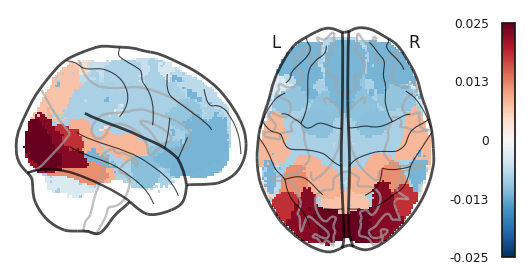

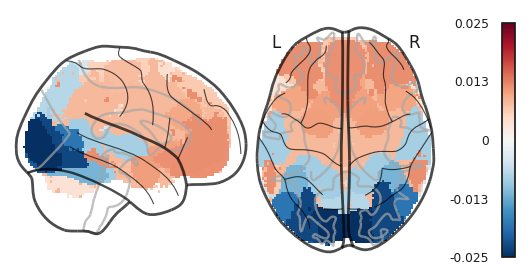

In [246]:
from nilearn.plotting import plot_glass_brain
import seaborn as sns

sns.set(font_scale=0.8)

Beta_session_brain = roi_to_brain(Beta_session, mask_x)
plot_glass_brain(Beta_session_brain.to_nifti(), display_mode='xz',colorbar=True,cmap='RdBu_r',plot_abs=False)
plt.savefig(os.path.join(current_directory,svg_file,"repetition_entire_brain_demean.svg"), format="svg")

Beta_autocorr_brain = roi_to_brain(Beta_autocorr, mask_x)
plot_glass_brain(Beta_autocorr_brain.to_nifti(), display_mode='xz',colorbar=True,cmap='RdBu_r',plot_abs=False)
plt.savefig(os.path.join(current_directory,svg_file,"proximity_entire_brain_demean.svg"), format="svg")


In [29]:
stats_p[32]

0.03498076181071563

In [9]:
stats_p = [0.06254182478365893,
 0.14955452065841865,
 0.2439137581370462,
 0.14340975503682085,
 0.00034952286133253064,
 0.4883401683881349,
 0.7478341942207739,
 0.11544240939385976,
 0.27903549989599685,
 0.37601141797532034,
 0.8245692797357719,
 0.07422787527129643,
 0.017271033449558305,
 0.1646994734456447,
 0.1296627506839427,
 0.9078974100566444,
 0.12621805607582665,
 0.21581605173589088,
 0.10663106692081052,
 0.3277078091419132,
 0.0006759588048746445,
 0.2804797668131484,
 0.2558193698476321,
 0.46070091372968336,
 0.24741261970742376,
 0.03940016946351709,
 0.13845221661783688,
 0.7832823286481629,
 0.13689536968956265,
 0.20807050340712013,
 0.4620247996666317,
 0.3378860049934913,
 0.03498076181071563,
 0.2405949708370057,
 0.04469640170286553,
 0.6901598691256767,
 0.49567868713006924,
 0.05943489913170227,
 0.2605421954627817,
 0.37523168890806347,
 0.45937127706838643,
 0.500781626471337,
 0.7166783090406927,
 0.0012311289976938793,
 0.2182495598166862,
 0.5826223195033965,
 0.009333754500555484,
 0.2620657136297035,
 0.571122975218013,
 0.998673640838104] 


In [7]:

fdr_thr = fdr(np.array(stats_p), 0.05)
sig_roi = np.array(list(range(50)))[np.array(stats_p < fdr_thr)]

In [13]:
fdr_thr

0.0012311289976938793

In [8]:
sig_roi

array([ 4, 20])

In [7]:
from nltools.stats import (threshold, 
                           align,
                           fdr, 
                           isc,
                           _calc_pvalue)
from scipy import stats
import numpy as np

In [15]:
def find_indices_smaller_than(lst, value):
    return [index for index, element in enumerate(lst) if element < value]

# Example usage
specific_value = 0.001
result = find_indices_smaller_than(stats_p, specific_value)
print(result) 

[4, 20]
